# US Superstore — Sales & Profit Analysis
This notebook loads the US Superstore dataset, preprocesses it, and answers business questions using visualizations.

In [ ]:
# Mini project
#loading the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Returns a DataFrame
df = pd.read_excel("US Superstore data.xls")
# Display the first 5 rows of the DataFrame
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

In [8]:
# Basic preprocessing: datatypes, missing values, and derived columns
df.columns.str.strip()
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')
print('Missing per column:', df.isna().sum())
# Drop rows with missing critical values (Order ID or Sales)
df = df.dropna(subset=['Order ID','Sales'])
# Ensure numeric types
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
df = df.dropna(subset=['Sales','Profit'])
df.shape

Missing per column: Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
dtype: int64


(9994, 23)

## 1) Which states have the most sales?
We'll aggregate sales and show a horizontal bar chart of top states.

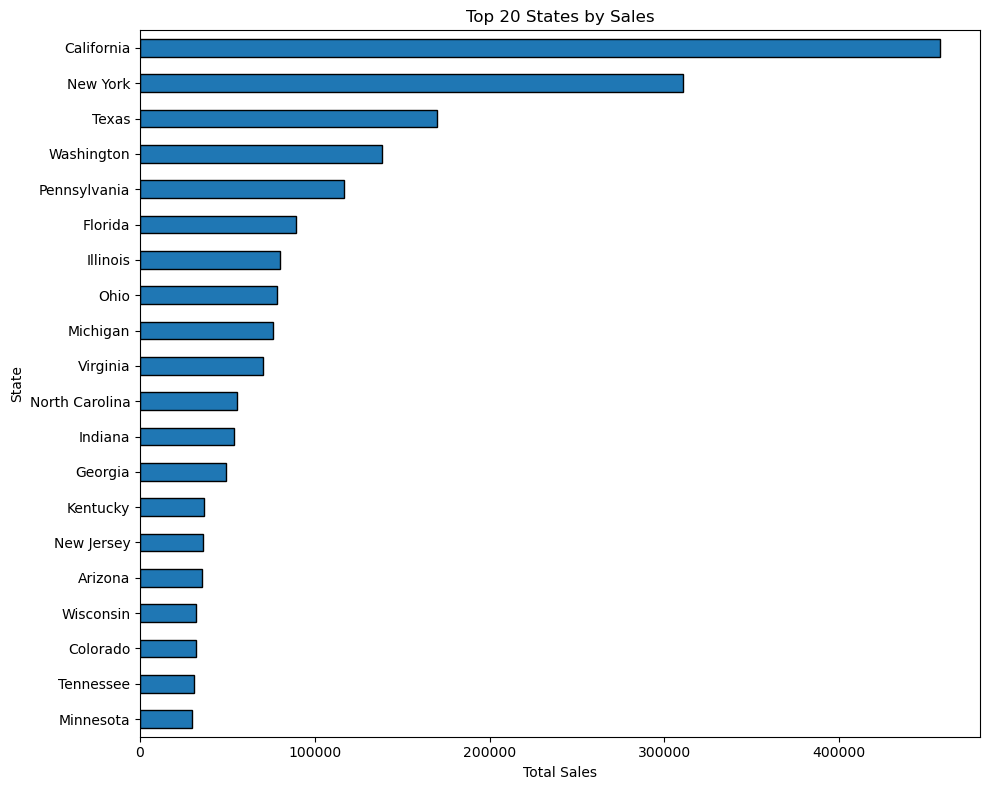

In [9]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,8))
state_sales.head(20).plot(kind='barh', color='C0', edgecolor='k')
plt.gca().invert_yaxis()
plt.xlabel('Total Sales')
plt.title('Top 20 States by Sales')
plt.tight_layout()
plt.show()

## 2) New York vs California: Sales and Profit
Compare total sales and profit between NY and CA.

In [10]:
states_cmp = df[df['State'].isin(['New York','California'])].groupby('State')[['Sales','Profit']].sum()
states_cmp

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486


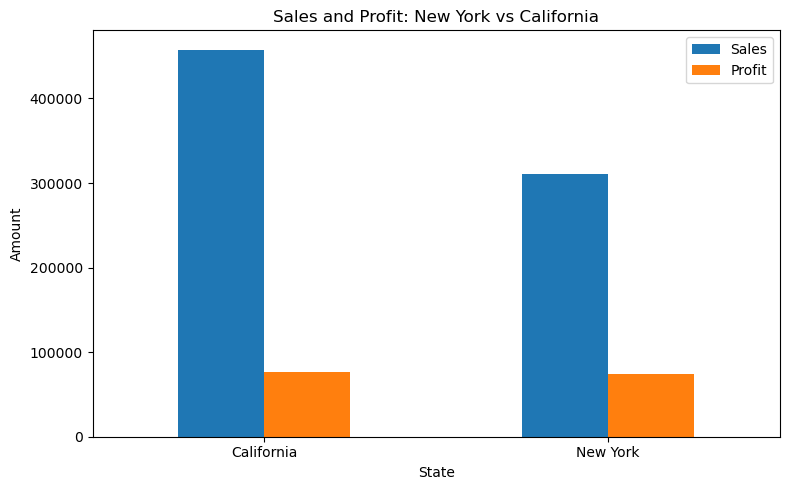

In [11]:
states_cmp.plot(kind='bar', figsize=(8,5), rot=0)
plt.title('Sales and Profit: New York vs California')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

## 3) Outstanding customer in New York
Find top customers in New York by sales and profit.

In [12]:
ny = df[df['State']=='New York']
top_ny_customers = ny.groupby('Customer Name')[['Sales','Profit']].sum().sort_values('Sales', ascending=False).head(10)
top_ny_customers

,Sales,Profit
Customer Name,,
Tom Ashbrook,13723.498,4599.2073
Peter Fuller,7678.228,543.2819
Seth Vernon,7359.918,1571.7964
Tom Boeckenhauer,6999.960,2239.9872
Greg Tran,6712.744,774.7935
Todd Sumrall,6492.314,1574.9714
Karen Daniels,6241.282,2283.0463
Keith Dawkins,5854.194,2510.8903
Luke Weiss,5048.186,773.1004


## 4) Differences among states in profitability
Compare profit margin (Profit / Sales) by state.

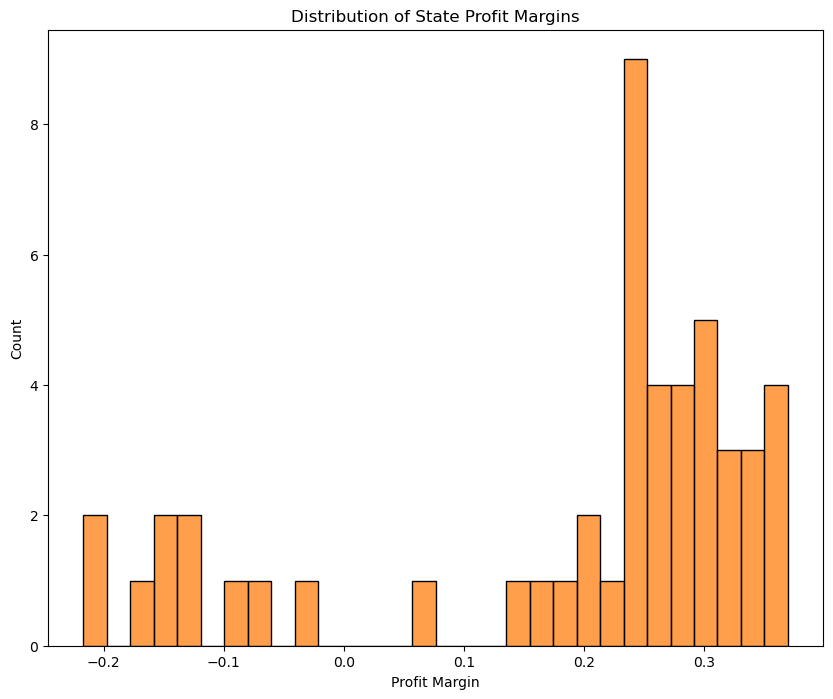

In [15]:
import seaborn as sns
state_perf = df.groupby('State')[['Sales','Profit']].sum()
state_perf['profit_margin'] = state_perf['Profit']/state_perf['Sales']
state_perf = state_perf.sort_values('profit_margin', ascending=False)
plt.figure(figsize=(10,8))
sns.histplot(state_perf['profit_margin'].dropna(), kde=False, bins=30, color='C1')
plt.title('Distribution of State Profit Margins')
plt.xlabel('Profit Margin')
plt.show()

## 5) Pareto principle on customers & Profit
Check whether 20% of customers produce ~80% of profit.

In [16]:
cust_profit = df.groupby('Customer ID')['Profit'].sum().sort_values(ascending=False)
cust_profit_cum = cust_profit.cumsum() / cust_profit.sum()
cust_share = pd.DataFrame({'profit':cust_profit, 'cum_pct':cust_profit_cum})
top20_count = int(0.2 * len(cust_share))
top20_share = cust_share['profit'].head(top20_count).sum() / cust_share['profit'].sum()
len(cust_share), top20_count, top20_share

(793, 158, np.float64(0.8142587496747005))

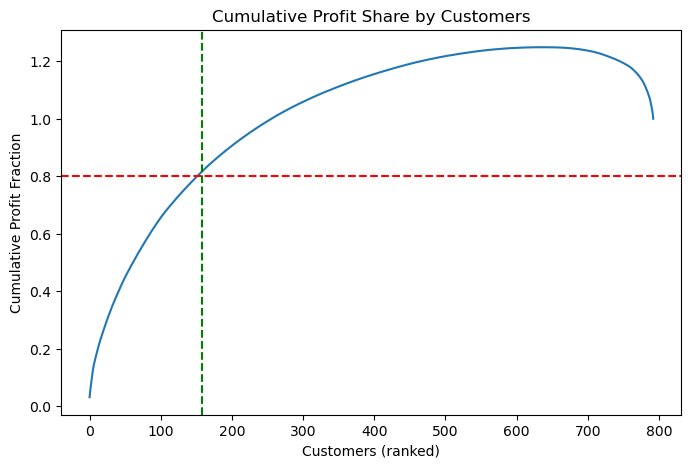

Top 20% customers contribute 81.43% of profit


In [17]:
plt.figure(figsize=(8,5))
cust_share['cum_pct'].reset_index(drop=True).plot()
plt.axhline(0.8, color='red', linestyle='--')
plt.axvline(top20_count, color='green', linestyle='--')
plt.title('Cumulative Profit Share by Customers')
plt.xlabel('Customers (ranked)')
plt.ylabel('Cumulative Profit Fraction')
plt.show()
print(f'Top 20% customers contribute {top20_share:.2%} of profit')

## 6) Top 20 cities by Sales and by Profit
Compare top cities and their profitability.

In [18]:
city_sales = df.groupby('City')[['Sales','Profit']].sum()
top20_sales_cities = city_sales.sort_values('Sales', ascending=False).head(20)
top20_profit_cities = city_sales.sort_values('Profit', ascending=False).head(20)
top20_sales_cities

,Sales,Profit
City,,
New York City,256368.1610,62036.9837
Los Angeles,175851.3410,30440.7579
Seattle,119540.7420,29156.0967
San Francisco,112669.0920,17507.3854
Philadelphia,109077.0130,-13837.7674
Houston,64504.7604,-10153.5485
Chicago,48539.5410,-6654.5688
San Diego,47521.0290,6377.1960
Jacksonville,44713.1830,-2323.8350


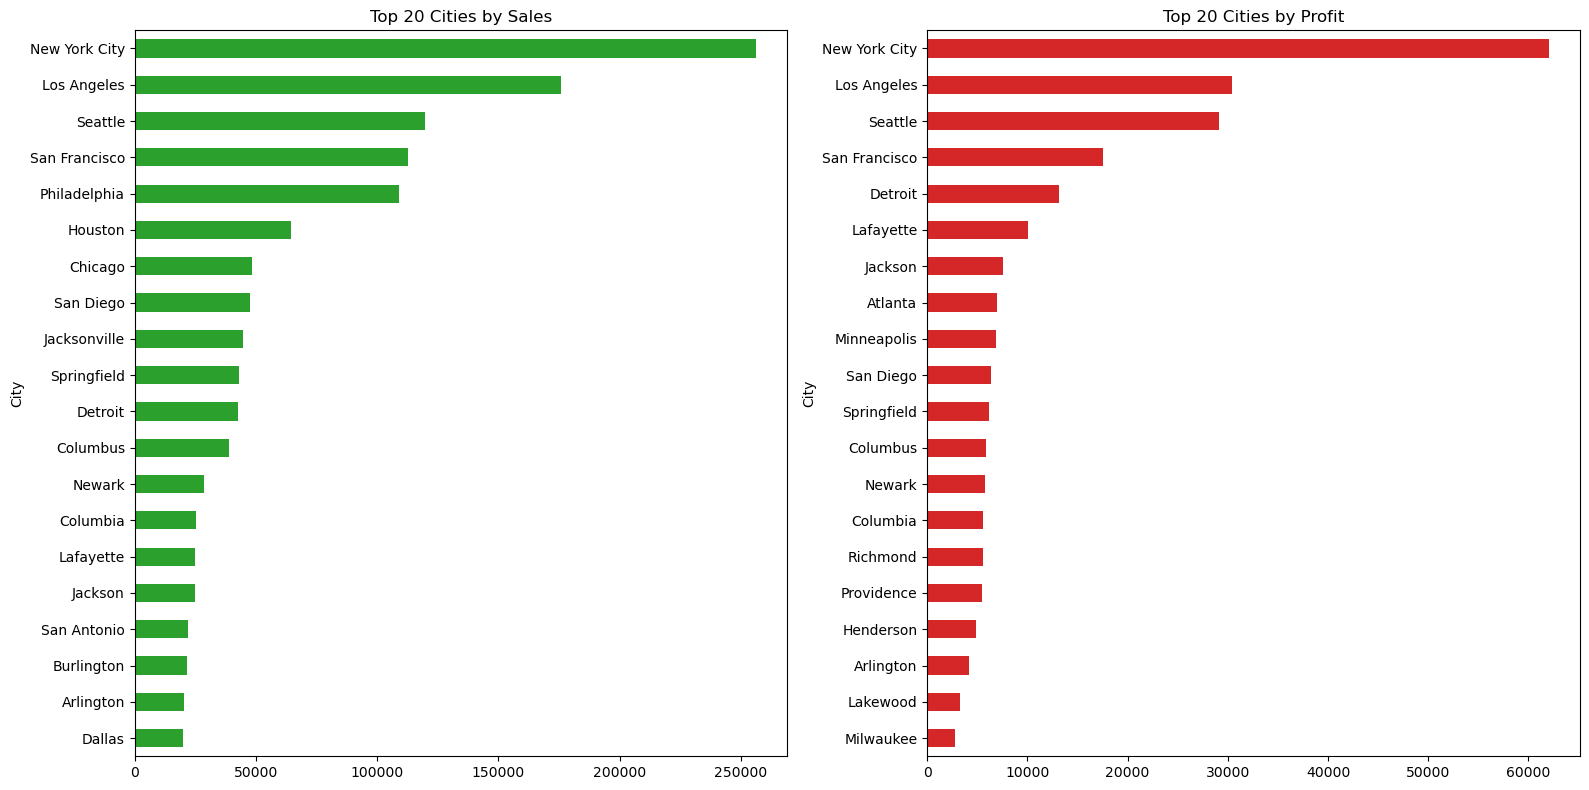

In [19]:
fig, axes = plt.subplots(1,2, figsize=(16,8))
top20_sales_cities['Sales'].sort_values().plot(kind='barh', ax=axes[0], color='C2')
axes[0].set_title('Top 20 Cities by Sales')
top20_profit_cities['Profit'].sort_values().plot(kind='barh', ax=axes[1], color='C3')
axes[1].set_title('Top 20 Cities by Profit')
plt.tight_layout()
plt.show()

## 7) Top 20 customers by Sales and cumulative sales curve

In [20]:
cust_sales = df.groupby('Customer ID')['Sales'].sum().sort_values(ascending=False)
top20_cust_sales = cust_sales.head(20)
top20_cust_sales

Customer ID
SM-20320    25043.050
TC-20980    19052.218
RB-19360    15117.339
TA-21385    14595.620
AB-10105    14473.571
KL-16645    14175.229
SC-20095    14142.334
HL-15040    12873.298
SE-20110    12209.438
CC-12370    12129.072
TS-21370    11891.751
GT-14710    11820.120
BM-11140    11789.630
SV-20365    11470.950
CJ-12010    11164.974
CL-12565    10880.546
ME-17320    10663.728
KF-16285    10604.266
BS-11365    10501.653
EH-13765    10310.880
Name: Sales, dtype: float64

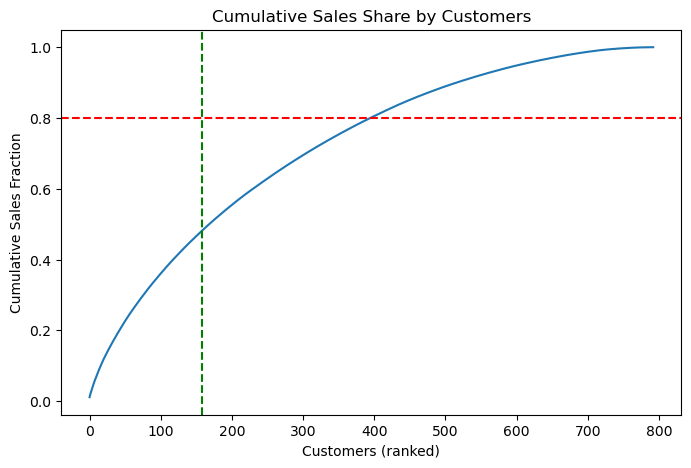

Top 20% customers contribute 47.96% of sales


In [21]:
# Cumulative sales curve
cust_sales_cum = cust_sales.cumsum() / cust_sales.sum()
plt.figure(figsize=(8,5))
cust_sales_cum.reset_index(drop=True).plot()
plt.axhline(0.8, color='red', linestyle='--')
top20_count_sales = int(0.2 * len(cust_sales_cum))
plt.axvline(top20_count_sales, color='green', linestyle='--')
plt.title('Cumulative Sales Share by Customers')
plt.xlabel('Customers (ranked)')
plt.ylabel('Cumulative Sales Fraction')
plt.show()
print(f'Top 20% customers contribute {cust_sales.head(top20_count_sales).sum()/cust_sales.sum():.2%} of sales')

## 8) Recommendations
Based on the findings, recommend states and cities to prioritize.

- Run targeted marketing in states with high sales and healthy profit margins.
- Prioritize top cities by sales but monitor profit margins to avoid unprofitable hotspots.
- Focus retention efforts on top customers contributing large shares of sales/profit (Pareto).